# DLthon 스타일 전용 검색 v2 — Colab 실행본

이 노트북은 사물의 종류가 아니라 **그리는 방식과 질감**을 검색합니다.

```text
한국어 입력
 → 내용·스타일 분리
 → 스타일 문장만 CLIP 검색
 → group-balanced 스타일 프로토타입 선택
 → Style Text + Style CLIP + Style Gram 결합
 → group 중복 없는 최종 Top 5
```

### Drive 프로젝트 폴더에 필요한 파일

- `daypack_v2.zip`
- `style_only_hybrid_v2_code.zip`

첫 실행은 CLIP·VGG19 모델 다운로드와 2,522장 특징 생성 때문에 오래 걸립니다. 이후에는
Drive의 특징 캐시를 재사용합니다. 셀은 위에서 아래로 순서대로 실행하세요.

## 1. GPU와 사용자 설정

Colab 메뉴에서 `런타임 → 런타임 유형 변경 → T4 GPU`를 먼저 선택하세요.

아래 셀에서 보통 수정할 값은 `MY_NAME`, `STYLE_QUERY` 두 개입니다. LLM 모델은 비용을
줄이기 위한 기본값을 넣었으며 계정에서 사용할 수 있는 다른 모델로 바꿀 수 있습니다.

In [1]:
MY_NAME = "김수경"
STYLE_QUERY = "수묵화 스타일의 사과"

# Query Rewriting 전용 모델. 단순 JSON 분리 작업이므로 비용 중심 기본값을 사용한다.
REWRITE_LLM_MODEL = "gpt-5.6-luna"

# 첫 기준선. 최종값이 아니라 검증셋에서 비교할 시작값이다.
STAGE1_TOP_K = 50
FINAL_TOP_K = 5
PROTOTYPE_TOP_N = 1
STYLE_TEXT_WEIGHT = 0.30
STYLE_CLIP_WEIGHT = 0.30
STYLE_GRAM_WEIGHT = 0.40

PROJECT_FOLDER_NAMES = ["DLthon_RAG", "DLthon_그림체RAG"]
print("이름:", MY_NAME)
print("검색어:", STYLE_QUERY)
print("LLM:", REWRITE_LLM_MODEL)

이름: 김수경
검색어: 수묵화 스타일의 사과
LLM: gpt-5.6-luna


In [2]:
import torch

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU가 활성화되지 않았습니다. 런타임 → 런타임 유형 변경 → T4 GPU를 선택하세요."
    )
print("GPU:", torch.cuda.get_device_name(0))

GPU: Tesla T4


## 2. Drive 연결과 프로젝트 폴더 탐색

Drive 폴더 후보 중 데이터 ZIP과 코드 ZIP을 모두 가진 폴더를 선택합니다. 폴더를 찾지
못하면 두 파일이 같은 `DLthon_RAG` 폴더 안에 있는지 확인하세요.

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
import os
from pathlib import Path

drive_roots = [Path("/content/drive/MyDrive")]
shared_root = Path("/content/drive/Shareddrives")
if shared_root.is_dir():
    drive_roots.extend(path for path in shared_root.iterdir() if path.is_dir())

candidates = []
for drive_root in drive_roots:
    for name in PROJECT_FOLDER_NAMES:
        direct = drive_root / name
        if direct.is_dir():
            candidates.append(direct)
        candidates.extend(path for path in drive_root.glob(f"*/{name}") if path.is_dir())

def find_code_source(folder):
    code_zip = list(folder.rglob("style_only_hybrid_v2_code.zip"))
    if code_zip:
        return code_zip[0]
    v2_files = list(folder.rglob("style_only_hybrid_langgraph_pipeline_v2.py"))
    base_files = list(folder.rglob("style_hybrid_langgraph_pipeline.py"))
    if v2_files and base_files:
        return (v2_files[0], base_files[0])
    return None

ready = []
for folder in dict.fromkeys(candidates):
    data_zip = folder / "daypack_v2.zip"
    code_source = find_code_source(folder)
    if data_zip.is_file() and code_source is not None:
        ready.append((folder, data_zip, code_source))

if not ready:
    found = "\n".join(f"- {folder}" for folder in candidates) or "- 후보 폴더 없음"
    raise SystemExit(
        "daypack_v2.zip과 style_only_hybrid_v2_code.zip을 함께 가진 프로젝트 폴더가 없습니다.\n"
        f"찾은 후보:\n{found}"
    )

PROJECT_DIR, DATA_ZIP, CODE_SOURCE = ready[0]
print("프로젝트:", PROJECT_DIR)
print("데이터:", DATA_ZIP.name)
print("코드:", CODE_SOURCE if isinstance(CODE_SOURCE, Path) else [p.name for p in CODE_SOURCE])

프로젝트: /content/drive/MyDrive/DLthon_RAG
데이터: daypack_v2.zip
코드: /content/drive/MyDrive/DLthon_RAG/style_only_hybrid_v2_code.zip


## 3. 패키지 설치

PyTorch와 torchvision은 Colab GPU 런타임에 설치된 버전을 그대로 사용합니다. LangGraph,
LLM 연결 모듈, Sentence Transformers만 설치합니다.

In [5]:
%pip -q install \
    "langgraph>=1.0,<2" \
    "langchain-openai>=1.0,<2" \
    "sentence-transformers>=3,<6"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.1/122.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.7/561.7 kB 22.6 MB/s eta 0:00:00


In [6]:
from importlib.metadata import version

for package in ["langgraph", "langchain-openai", "sentence-transformers", "torch", "torchvision"]:
    print(f"{package:24s}", version(package))

langgraph                1.2.9
langchain-openai         1.4.1
sentence-transformers    5.6.0
torch                    2.11.0+cu128
torchvision              0.26.0+cu128


## 4. 데이터와 코드 안전하게 준비

ZIP 내부에 상위 폴더가 한 겹 더 있어도 marker 파일로 실제 루트를 찾습니다. 경로 이탈이
있는 ZIP은 중단합니다. 데이터·코드는 Colab 로컬에 풀고, 큰 특징 캐시는 Drive에 저장합니다.

In [7]:
import shutil
import sys
import tempfile
import zipfile

def extract_zip_safe(zip_path, destination):
    destination = Path(destination).resolve()
    destination.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path) as archive:
        for member in archive.infolist():
            relative = member.filename.replace("\\", "/").lstrip("/")
            if not relative:
                continue
            target = (destination / relative).resolve()
            if target != destination and destination not in target.parents:
                raise RuntimeError(f"안전하지 않은 ZIP 경로: {member.filename}")
            if member.is_dir() or relative.endswith("/"):
                target.mkdir(parents=True, exist_ok=True)
            else:
                target.parent.mkdir(parents=True, exist_ok=True)
                with archive.open(member) as source, target.open("wb") as output:
                    shutil.copyfileobj(source, output)

def find_marked_root(search_root, markers):
    matches = []
    for root, directories, files in os.walk(search_root):
        present = set(directories) | set(files)
        if all(marker in present for marker in markers):
            matches.append(Path(root))
    if len(matches) != 1:
        raise RuntimeError(f"marker root를 하나로 정하지 못했습니다: {markers}, {matches}")
    return matches[0]

local_data = Path("/content/daypack_v2")
local_code = Path("/content/style_search_v2")
staging = Path(tempfile.mkdtemp(prefix="style_search_setup_", dir="/content"))
try:
    data_stage = staging / "data"
    extract_zip_safe(DATA_ZIP, data_stage)
    detected_data = find_marked_root(data_stage, ["meta.csv", "VERSION.json", "images"])
    if local_data.is_dir():
        shutil.rmtree(local_data)
    shutil.copytree(detected_data, local_data)

    if local_code.is_dir():
        shutil.rmtree(local_code)
    local_code.mkdir(parents=True)
    if isinstance(CODE_SOURCE, Path):
        code_stage = staging / "code"
        extract_zip_safe(CODE_SOURCE, code_stage)
        detected_v2 = list(code_stage.rglob("style_only_hybrid_langgraph_pipeline_v2.py"))
        detected_base = list(code_stage.rglob("style_hybrid_langgraph_pipeline.py"))
        if len(detected_v2) != 1 or len(detected_base) != 1:
            raise RuntimeError("코드 ZIP에서 필요한 Python 파일 두 개를 찾지 못했습니다.")
        shutil.copy2(detected_v2[0], local_code / detected_v2[0].name)
        shutil.copy2(detected_base[0], local_code / detected_base[0].name)
    else:
        for source in CODE_SOURCE:
            shutil.copy2(source, local_code / source.name)
finally:
    shutil.rmtree(staging, ignore_errors=True)

required = [
    local_data / "meta.csv",
    local_data / "VERSION.json",
    local_data / "images",
    local_code / "style_hybrid_langgraph_pipeline.py",
    local_code / "style_only_hybrid_langgraph_pipeline_v2.py",
]
missing = [str(path) for path in required if not path.exists()]
if missing:
    raise RuntimeError("준비 후 필요한 파일이 없습니다:\n" + "\n".join(missing))

if str(local_code) not in sys.path:
    sys.path.insert(0, str(local_code))
print("데이터 준비:", local_data)
print("코드 준비:", local_code)

데이터 준비: /content/daypack_v2
코드 준비: /content/style_search_v2


In [8]:
import csv

with (local_data / "meta.csv").open(encoding="utf-8") as stream:
    meta_rows = list(csv.DictReader(stream))
styles = sorted({row["style"] for row in meta_rows})
if len(meta_rows) != 2522 or len(styles) != 20:
    raise RuntimeError(
        f"daypack_v2 구성이 예상과 다릅니다: 이미지={len(meta_rows)}, 스타일={len(styles)}"
    )
print("데이터 검증 완료:", len(meta_rows), "장 /", len(styles), "스타일")

데이터 검증 완료: 2522 장 / 20 스타일


## 5. API 키 연결

Colab 왼쪽 열쇠 모양 `Secrets`에 `OPENAI_API_KEY`를 저장하고 Notebook access를 켜세요.
Secret이 없으면 화면에 보이지 않는 안전 입력창이 나타납니다. 키 값은 출력하거나 파일에
저장하지 않습니다.

In [9]:
import getpass
from google.colab import userdata

try:
    api_key = userdata.get("OPENAI_API_KEY")
except Exception:
    api_key = None
if not api_key:
    api_key = getpass.getpass("OPENAI_API_KEY: ")
if not api_key:
    raise RuntimeError("API 키가 입력되지 않았습니다.")
os.environ["OPENAI_API_KEY"] = api_key
del api_key
print("API 키 연결 완료 — 값은 표시하지 않습니다.")

OPENAI_API_KEY: ··········
API 키 연결 완료 — 값은 표시하지 않습니다.


## 6. 스타일 검색 파이프라인 준비

최초 실행에서는 다음 특징을 생성합니다.

- CLIP 이미지 특징: 512차원
- VGG19 저층 Gram 특징: 10,336차원
- 동일 원본·내용 group을 동일 가중치로 처리한 스타일 프로토타입

특징 캐시는 Drive에 저장되므로 같은 데이터와 모델에서는 다음 실행부터 재사용합니다.

In [10]:
from langchain_openai import ChatOpenAI
from style_only_hybrid_langgraph_pipeline_v2 import (
    StylePipelineConfig,
    prepare_style_pipeline,
    public_result,
    run_style_search,
)

FEATURE_CACHE_DIR = PROJECT_DIR / "cache" / "style_search_v2" / "features"
REWRITE_CACHE_DIR = PROJECT_DIR / "cache" / "style_search_v2" / "rewrites"
RESULTS_DIR = PROJECT_DIR / "results" / MY_NAME / "style_search_v2"
FEATURE_CACHE_DIR.mkdir(parents=True, exist_ok=True)
REWRITE_CACHE_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = StylePipelineConfig(
    stage1_top_k=STAGE1_TOP_K,
    final_top_k=FINAL_TOP_K,
    prototype_top_n=PROTOTYPE_TOP_N,
    text_weight=STYLE_TEXT_WEIGHT,
    clip_weight=STYLE_CLIP_WEIGHT,
    gram_weight=STYLE_GRAM_WEIGHT,
)

# temperature를 받지 않는 reasoning 모델과도 호환되도록 모델 기본 설정을 사용한다.
# 재현성은 model 이름·prompt version·rewrite cache로 관리한다.
rewrite_llm = ChatOpenAI(model=REWRITE_LLM_MODEL, max_retries=2)

graph, services = prepare_style_pipeline(
    pack_dir=local_data,
    llm=rewrite_llm,
    rewrite_model_id=REWRITE_LLM_MODEL,
    feature_cache_dir=FEATURE_CACHE_DIR,
    rewrite_cache_dir=REWRITE_CACHE_DIR,
    config=CONFIG,
    device="cuda",
)
print("파이프라인 준비 완료")
print("특징 캐시:", FEATURE_CACHE_DIR)
print("결과 폴더:", RESULTS_DIR)

modules.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/1.91k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.03k [00:00<?, ?B/s]

0_CLIPModel/model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/115 [00:00<?, ?B/s]

2_Dense/model.safetensors: reconstructing file:   0%|          |  0.00B / 1.57MB            

2_Dense/model.safetensors: downloading bytes:           |  0.00B            

파이프라인 준비 완료
특징 캐시: /content/drive/MyDrive/DLthon_RAG/cache/style_search_v2/features
결과 폴더: /content/drive/MyDrive/DLthon_RAG/results/김수경/style_search_v2


## 7. 단일 스타일 검색 실행

결과에는 원문, 생성 단계용 내용, 검색에 사용한 스타일 문장, 스타일 후보, 최종 점수의
Text·CLIP·Gram 분해가 모두 남습니다. `status=success`가 아니면 결과를 사용하지 않습니다.

In [11]:
import json

state = run_style_search(graph, STYLE_QUERY, CONFIG)
result = public_result(state)

if result["status"] != "success":
    print(json.dumps(result["errors"], ensure_ascii=False, indent=2))
    raise RuntimeError("스타일 검색이 실패했습니다. 위 오류를 확인하세요.")

result_path = RESULTS_DIR / f"search_{result['request_id']}.json"
result_path.write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding="utf-8")

parts = result["query_parts"]
print("원문:", result["user_query"])
print("생성용 내용(검색 미사용):", parts["content_prompt_en"] or parts["content_prompt_source"])
print("검색용 스타일:", parts["style_prompt_en"])
print("재작성 출처:", parts["rewrite_source"])
print("스타일 후보:", result["ranked_style_names"][:5])
print("선택 프로토타입:", result["selected_prototype_style_names"])
print("최종 스타일:", result["final_styles"])
print("저장:", result_path)

원문: 수묵화 스타일의 사과
생성용 내용(검색 미사용): A single apple
검색용 스타일: Traditional East Asian ink wash painting, expressive fluid brushwork, varied calligraphic line weight, soft bleeding ink edges, layered translucent washes, restrained black and gray tonal range, subtle muted red accents, absorbent textured paper, spacious negative space, minimal asymmetrical composition
재작성 출처: llm
스타일 후보: ['ink_m6', 'ink_m9', 'ink_m8', 'vec_irasutoya', 'ink_m4']
선택 프로토타입: ['ink_m6']
최종 스타일: ['ink_m6', 'ink_m6', 'ink_m6', 'ink_m9', 'ink_m4']
저장: /content/drive/MyDrive/DLthon_RAG/results/김수경/style_search_v2/search_7451e5eb290044f88e8e03fd872f7db1.json


/tmp/ipykernel_1755/2594675201.py:22: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1755/2594675201.py:22: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1755/2594675201.py:22: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1755/2594675201.py:22: UserWarning: Glyph 53440 (\N{HANGUL SYLLABLE TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1755/2594675201.py:22: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1755/2594675201.py:22: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1755/2594675201.py:22: UserWarning: Glyph 49353 (\N{HANGUL SYLLABLE SAEG}) missing from font(s) DejaVu Sans.
  plt.tight_

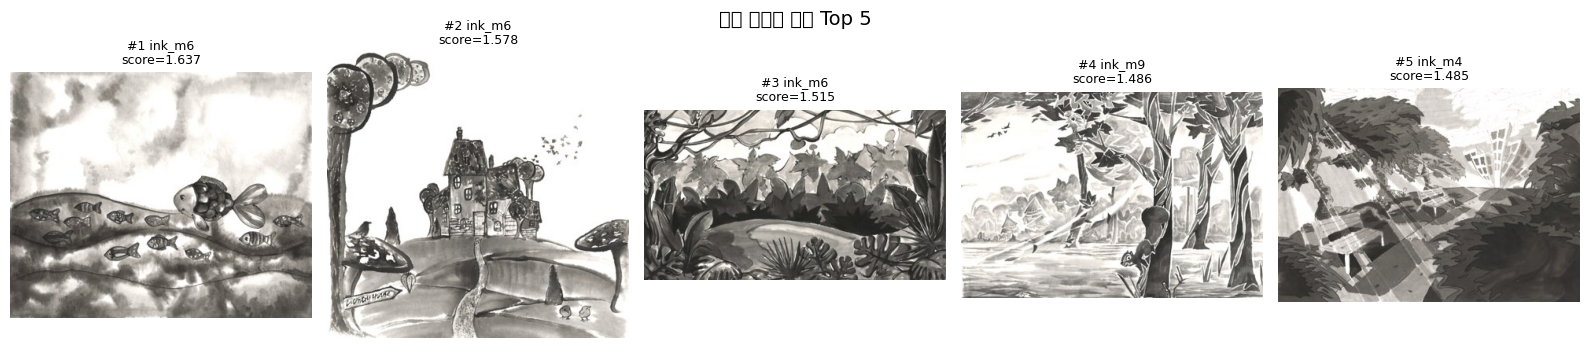

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def show_results(indices, scores, title, columns=5):
    rows = (len(indices) + columns - 1) // columns
    fig, axes = plt.subplots(rows, columns, figsize=(3.2 * columns, 3.5 * rows))
    axes = np.asarray(axes).reshape(-1)
    corpus = services.search_index.corpus
    for axis in axes:
        axis.axis("off")
    for rank, (index, score) in enumerate(zip(indices, scores), 1):
        axis = axes[rank - 1]
        with Image.open(corpus.paths[index]) as image:
            axis.imshow(image.convert("RGB"))
        axis.set_title(
            f"#{rank} {corpus.styles[index]}\nscore={score:.3f}",
            fontsize=9,
        )
        axis.axis("off")
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

show_results(
    state["final_indices"],
    state["final_scores"],
    "최종 스타일 검색 Top 5",
)

In [13]:
print("[최종 점수 분해]")
for row in result["final_score_breakdown"]:
    print(
        f"{row['style']:24s}",
        f"text={row['text_style_score']:+.3f}",
        f"clip={row['clip_prototype_score']:+.3f}",
        f"gram={row['gram_prototype_score']:+.3f}",
        f"final={row['final_score']:+.3f}",
    )

print("\n[노드 실행 기록]")
for event in result["audit_log"]:
    print(event["node"], event["outcome"], f"{event['elapsed_ms']:.1f}ms")

[최종 점수 분해]
ink_m6                   text=+0.288 clip=+0.867 gram=+0.990 final=+1.637
ink_m6                   text=+0.276 clip=+0.893 gram=+0.987 final=+1.578
ink_m6                   text=+0.286 clip=+0.885 gram=+0.950 final=+1.515
ink_m9                   text=+0.285 clip=+0.873 gram=+0.957 final=+1.486
ink_m4                   text=+0.279 clip=+0.892 gram=+0.960 final=+1.485

[노드 실행 기록]
rewrite_query success 3994.9ms
text_search success 12.8ms
extract_image_features success 0.2ms
final_image_search success 9.7ms


## 8. 다른 검색어 반복 실행

특징 인덱스와 그래프는 다시 만들지 않습니다. 새 문장의 Query Rewriting만 호출하며 동일
문장은 Drive rewrite cache를 사용합니다.

In [14]:
def search_style(user_query, show=True):
    current_state = run_style_search(graph, user_query, CONFIG)
    current_result = public_result(current_state)
    output_path = RESULTS_DIR / f"search_{current_result['request_id']}.json"
    output_path.write_text(
        json.dumps(current_result, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    if current_result["status"] != "success":
        print("실패:", current_result["errors"])
        return current_state
    print("원문:", user_query)
    print("스타일 문장:", current_result["query_parts"]["style_prompt_en"])
    print("최종 스타일:", current_result["final_styles"])
    if show:
        show_results(
            current_state["final_indices"],
            current_state["final_scores"],
            user_query,
        )
    return current_state

# 사용 예시
# another_state = search_style("거친 목탄 스케치 스타일의 고양이")

## 9. 종료 전 확인

- `query_parts.content_prompt_*`는 생성 단계용이며 검색 점수에는 사용되지 않습니다.
- `query_parts.style_prompt_en`만 검색됩니다.
- 결과 JSON과 특징·재작성 캐시는 Drive에 남습니다.
- 가중치를 변경할 때는 한 번에 하나의 가설만 바꾸고 같은 평가 쿼리에서 비교하세요.
- 실제 성능 판정은 단일 예시가 아니라 Style-Macro mAP@5와 대응 95% 구간으로 합니다.